# 2. Optimizer convergence and cost

Compare RHC, SA, GA, and Adam on classification and regression. RHC accepts
non-increasing loss, SA may accept worse moves according to temperature, GA
persists a population across generations, and Adam follows gradients. Equal call
counts do not imply
equal work; this compares fixed settings rather than elapsed-time performance.

Each task has 360 generated observations and a fixed 75/25 train/validation split
(data/split seed 7), training-only standardization, and a tanh network with hidden
width 8. Seeds 11, 22, and 33 pair the data and initial model across optimizers.
Runs use float32 CPU, one Torch thread, full-batch loss, and 160 optimizer calls
without RHC restarts. For GA, the first call initializes its population and the
remaining 159 calls are generations. Classification uses cross-entropy; regression
uses MSE on
standardized targets. Hyperparameters are fixed below.

In [1]:
import hashlib
import importlib.metadata
import platform
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

import pyperch
from pyperch.plotting import plot_training_curve, prepare_training_curve

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
started = perf_counter()
print("Python", platform.python_version(), "|", platform.system(), platform.machine())
print(
    {
        p: importlib.metadata.version(p)
        for p in ["torch", "numpy", "matplotlib", "scikit-learn", "optuna"]
    }
)
optimizer_dir = Path(pyperch.__file__).parent / "optim"
print(
    "Optimizer SHA256:",
    {
        p.name: hashlib.sha256(p.read_bytes()).hexdigest()[:12]
        for p in sorted(optimizer_dir.glob("*.py"))
    },
)

Python 3.12.13 | Darwin arm64
{'torch': '2.12.0', 'numpy': '2.2.6', 'matplotlib': '3.10.9', 'scikit-learn': '1.7.2', 'optuna': '4.8.0'}
Optimizer SHA256: {'__init__.py': '689555afdfc1', 'base.py': '99736e2f4cd2', 'ga.py': '2efcfab3ac45', 'rhc.py': '47cda7de86b1', 'sa.py': '8ca21675749b'}


## Record losses and costs

Count every objective closure call. Monitoring adds two forward passes per
recorded point, one for training and one for validation, reported separately.
Adam's backward work is excluded, so objective counts are not equivalent compute
budgets.

Call 0 records the starting model. RHC and SA initialize cached loss on their first
call; GA evaluates its complete initial population; Adam already updates. Later GA
calls are persistent generations. Curves show current parameters. Final scores
use each optimizer's lowest training-loss checkpoint, including Adam, without
selecting on validation.

In [2]:
from copy import deepcopy

from sklearn.datasets import make_classification, make_regression
from sklearn.metrics import f1_score, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from pyperch.optim import GA, RHC, SA

SEEDS = [11, 22, 33]
CALLS = 160
names = ["RHC", "SA", "GA", "Adam"]
settings = {
    "RHC": {"step_size": 0.06},
    "SA": {
        "step_size": 0.15,
        "temperature": 0.03,
        "min_temperature": 0.001,
        "cooling": 0.97,
    },
    "GA": {
        "population_size": 16,
        "mutation_rate": 0.15,
        "initialization_step_size": 0.08,
        "mutation_step_size": 0.04,
    },
    "Adam": {"lr": 0.03},
}
print("Fixed settings:", settings)


def make_data(task):
    if task == "Classification":
        X, y = make_classification(
            n_samples=360,
            n_features=6,
            n_informative=4,
            n_redundant=0,
            class_sep=1.2,
            random_state=7,
        )
    else:
        X, y = make_regression(
            n_samples=360, n_features=6, n_informative=4, noise=15, random_state=7
        )
    Xt, Xv, yt, yv = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=7,
        stratify=y if task == "Classification" else None,
    )
    scaler = StandardScaler().fit(Xt)
    Xt, Xv = [torch.tensor(scaler.transform(a), dtype=torch.float32) for a in (Xt, Xv)]
    if task == "Regression":
        center, scale = yt.mean(), yt.std()
        yt, yv = [(a - center)[:, None] / scale for a in (yt, yv)]
    dtype = torch.long if task == "Classification" else torch.float32
    return Xt, Xv, torch.tensor(yt, dtype=dtype), torch.tensor(yv, dtype=dtype)


def run(task, name, seed, data):
    Xt, Xv, yt, yv = data
    torch.manual_seed(seed)
    model = nn.Sequential(
        nn.Linear(6, 8), nn.Tanh(), nn.Linear(8, 2 if task == "Classification" else 1)
    )
    loss_fn = nn.CrossEntropyLoss() if task == "Classification" else nn.MSELoss()
    constructors = {"RHC": RHC, "SA": SA, "GA": GA, "Adam": torch.optim.Adam}
    options = settings[name] | ({"random_state": seed} if name != "Adam" else {})
    optimizer = constructors[name](model.parameters(), **options)
    objective_calls = 0
    monitoring_calls = 0
    history = {
        key: []
        for key in ["train", "valid", "best", "evals", "temperature", "acceptance"]
    }

    def objective():
        nonlocal objective_calls
        objective_calls += 1
        with torch.set_grad_enabled(name == "Adam"):
            return loss_fn(model(Xt), yt)

    best_loss = float("inf")
    best_weights = None
    for call in range(CALLS + 1):
        if call:
            if name == "Adam":
                optimizer.zero_grad()
                loss = objective()
                loss.backward()
                optimizer.step()
            else:
                optimizer.step(objective)
        with torch.no_grad():
            train = loss_fn(model(Xt), yt).item()
            valid = loss_fn(model(Xv), yv).item()
        monitoring_calls += 2
        if train < best_loss:
            best_loss, best_weights = train, deepcopy(model.state_dict())
        history["train"].append(train)
        history["valid"].append(valid)
        history["best"].append(best_loss)
        history["evals"].append(objective_calls)
        if name == "SA":
            history["temperature"].append(optimizer.temperature)
            proposals = optimizer.proposed_steps
            history["acceptance"].append(
                optimizer.accepted_steps / proposals if proposals else 0.0
            )
    if name == "Adam":
        model.load_state_dict(best_weights)
    else:
        assert optimizer.function_evals == objective_calls
        if name == "GA":
            assert optimizer.proposed_steps == CALLS - 1
            assert (
                optimizer.accepted_steps + optimizer.rejected_steps
                == optimizer.proposed_steps
            )
        optimizer.restore_best()
    with torch.no_grad():
        output = model(Xv)
        restored_valid = loss_fn(output, yv).item()
    if task == "Classification":
        pred = output.argmax(1).numpy()
        scores = {
            "accuracy": float((pred == yv.numpy()).mean()),
            "F1": f1_score(yv.numpy(), pred, zero_division=0),
        }
    else:
        scores = {"R2": r2_score(yv.numpy(), output.numpy())}
    history["summary"] = {
        "seed": seed,
        "generations": optimizer.proposed_steps if name == "GA" else "n/a",
        "objective_calls": objective_calls,
        "monitoring_calls": monitoring_calls,
        "final_validation_passes": 1,
        "restored_validation_loss": restored_valid,
    } | scores
    return history


results = {}
for task in ["Classification", "Regression"]:
    data = make_data(task)
    results[task] = {
        name: [run(task, name, seed, data) for seed in SEEDS] for name in names
    }
print("Completed 24 independent runs; seeds:", SEEDS)

Fixed settings: {'RHC': {'step_size': 0.06}, 'SA': {'step_size': 0.15, 'temperature': 0.03, 'min_temperature': 0.001, 'cooling': 0.97}, 'GA': {'population_size': 16, 'mutation_rate': 0.15, 'initialization_step_size': 0.08, 'mutation_step_size': 0.04}, 'Adam': {'lr': 0.03}}


Completed 24 independent runs; seeds: [11, 22, 33]


These training curves show loss versus optimizer calls. Lines are means over three
seeds; ribbons are mean ± sample SD (`ddof=1`). With a fixed dataset and split, the
spread reflects initialization and optimizer randomness, not uncertainty across
datasets or a confidence interval. SD bands are not clipped to metric bounds.

Read each row in its own units. Training improvement without validation improvement
can signal overfitting; plateaus in both can reflect optimization limits or
insufficient model capacity.

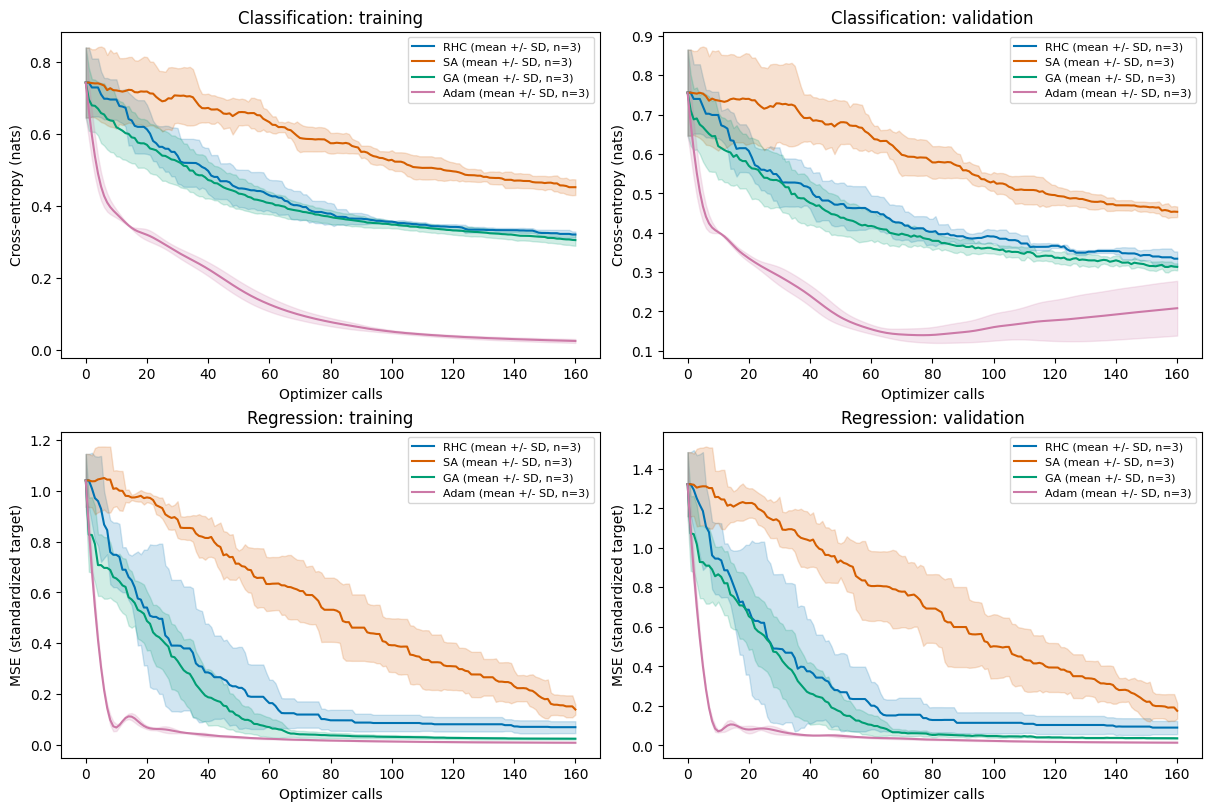

In [3]:
x = np.arange(CALLS + 1)
colors = {"RHC": "#0072B2", "SA": "#D55E00", "GA": "#009E73", "Adam": "#CC79A7"}
styles = {name: {"color": color} for name, color in colors.items()}
fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
for row, (task, by_optimizer) in enumerate(results.items()):
    metric = (
        "Cross-entropy (nats)"
        if task == "Classification"
        else "MSE (standardized target)"
    )
    for col, split in enumerate(["train", "valid"]):
        values = {
            name: np.array([r[split] for r in runs]).T
            for name, runs in by_optimizer.items()
        }
        curve = prepare_training_curve(
            x, values, metric=metric, x_label="Optimizer calls"
        )
        plot_training_curve(curve, ax=axes[row, col], line_kwargs=styles)
        axes[row, col].set_title(
            f"{task}: {'training' if split == 'train' else 'validation'}"
        )
        axes[row, col].legend(fontsize=8)
plt.show()

## Measured objective calls

GA evaluates its full population once, then reuses surviving elite losses and
evaluates only new children in each generation. Replot the same runs on each
optimizer's
measured evaluation grid, checking that grids match across seeds. There is no
interpolation or padding; endpoints reflect different objective budgets. Counts
include initialization; x=0 is the monitored starting model.

Monitoring and backward work are excluded from this axis. The symlog scale is
linear from 0 to 10 and logarithmic thereafter, keeping both initialization and
larger counts visible.

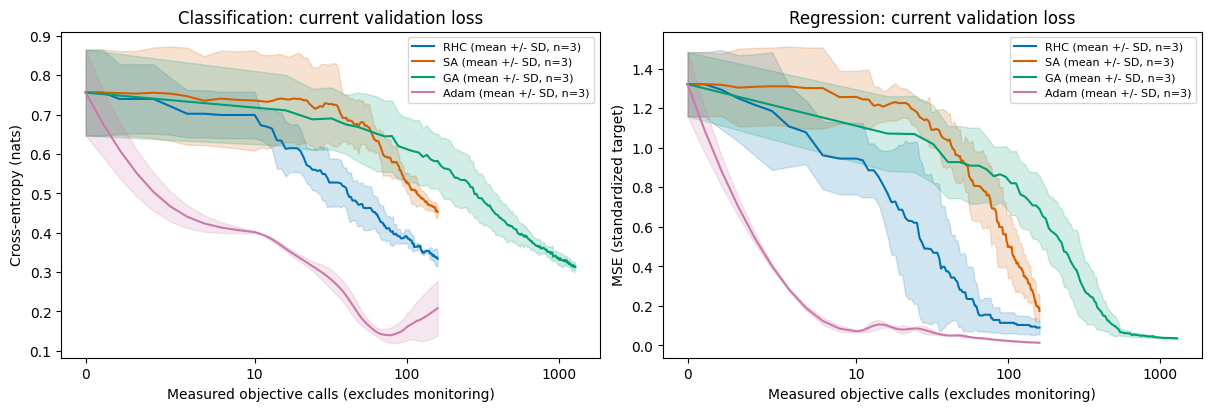

### Classification: restored checkpoints
| Optimizer | Seed | Generations | Objective calls | Validation loss | Accuracy / R2 | F1 |
| --- | --- | --- | --- | --- | --- | --- |
| RHC | 11 | n/a | 160 | 0.3458 | 0.844 | 0.851 |
| RHC | 22 | n/a | 160 | 0.3130 | 0.878 | 0.884 |
| RHC | 33 | n/a | 160 | 0.3437 | 0.867 | 0.872 |
| SA | 11 | n/a | 160 | 0.4382 | 0.856 | 0.863 |
| SA | 22 | n/a | 160 | 0.4645 | 0.822 | 0.826 |
| SA | 33 | n/a | 160 | 0.4547 | 0.833 | 0.831 |
| GA | 11 | 159 | 1288 | 0.3237 | 0.900 | 0.903 |
| GA | 22 | 159 | 1288 | 0.3078 | 0.867 | 0.875 |
| GA | 33 | 159 | 1288 | 0.3085 | 0.878 | 0.882 |
| Adam | 11 | n/a | 160 | 0.2280 | 0.956 | 0.956 |
| Adam | 22 | n/a | 160 | 0.2659 | 0.933 | 0.935 |
| Adam | 33 | n/a | 160 | 0.1311 | 0.956 | 0.956 |

### Regression: restored checkpoints
| Optimizer | Seed | Generations | Objective calls | Validation loss | Accuracy / R2 | F1 |
| --- | --- | --- | --- | --- | --- | --- |
| RHC | 11 | n/a | 160 | 0.0792 | 0.939 | n/a |
| RHC | 22 | n/a | 160 | 0.1280 | 0.901 | n/a |
| RHC | 33 | n/a | 160 | 0.0632 | 0.951 | n/a |
| SA | 11 | n/a | 160 | 0.1611 | 0.875 | n/a |
| SA | 22 | n/a | 160 | 0.2205 | 0.829 | n/a |
| SA | 33 | n/a | 160 | 0.1421 | 0.890 | n/a |
| GA | 11 | 159 | 1288 | 0.0395 | 0.969 | n/a |
| GA | 22 | 159 | 1288 | 0.0322 | 0.975 | n/a |
| GA | 33 | 159 | 1288 | 0.0363 | 0.972 | n/a |
| Adam | 11 | n/a | 160 | 0.0141 | 0.989 | n/a |
| Adam | 22 | n/a | 160 | 0.0127 | 0.990 | n/a |
| Adam | 33 | n/a | 160 | 0.0152 | 0.988 | n/a |

Every run also used 322 monitoring forwards and 1 restored validation forward.


In [4]:
from IPython.display import Markdown, display

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for ax, (task, by_optimizer) in zip(axes, results.items()):
    metric = (
        "Cross-entropy (nats)"
        if task == "Classification"
        else "MSE (standardized target)"
    )
    for name, runs in by_optimizer.items():
        grid = runs[0]["evals"]
        assert all(r["evals"] == grid for r in runs)
        curve = prepare_training_curve(
            grid,
            {name: np.array([r["valid"] for r in runs]).T},
            metric=metric,
            x_label="Measured objective calls (excludes monitoring)",
        )
        plot_training_curve(curve, ax=ax, line_kwargs={name: styles[name]})
    ax.set_xscale("symlog", linthresh=10)
    ax.set_xticks([0, 10, 100, 1000], labels=["0", "10", "100", "1000"])
    ax.set_title(f"{task}: current validation loss")
    ax.legend(fontsize=8)
plt.show()

for task, by_optimizer in results.items():
    rows = [
        f"### {task}: restored checkpoints",
        (
            "| Optimizer | Seed | Generations | Objective calls | "
            "Validation loss | Accuracy / R2 | F1 |"
        ),
        "| --- | --- | --- | --- | --- | --- | --- |",
    ]
    for name, runs in by_optimizer.items():
        for run_result in runs:
            summary = run_result["summary"]
            score = summary.get("accuracy", summary.get("R2"))
            f1 = f"{summary['F1']:.3f}" if "F1" in summary else "n/a"
            rows.append(
                f"| {name} | {summary['seed']} | {summary['generations']} | "
                f"{summary['objective_calls']} | "
                f"{summary['restored_validation_loss']:.4f} | {score:.3f} | {f1} |"
            )
    display(Markdown("\n".join(rows)))
print("Every run also used 322 monitoring forwards and 1 restored validation forward.")

## SA diagnostics

SA's current loss can rise while its best observed training loss stays unchanged
or falls. Neither guarantees better validation performance. The deterministic
temperature schedule needs one line. Cumulative acceptance starts at call 2,
after the first proposal; initialization is not a rejection. GA's accepted and
rejected counters instead describe whether whole generations improve its incumbent.

The table above lists all three restored validation scores: accuracy/F1 for
classification and R² for regression. Higher is better; R² can be negative.

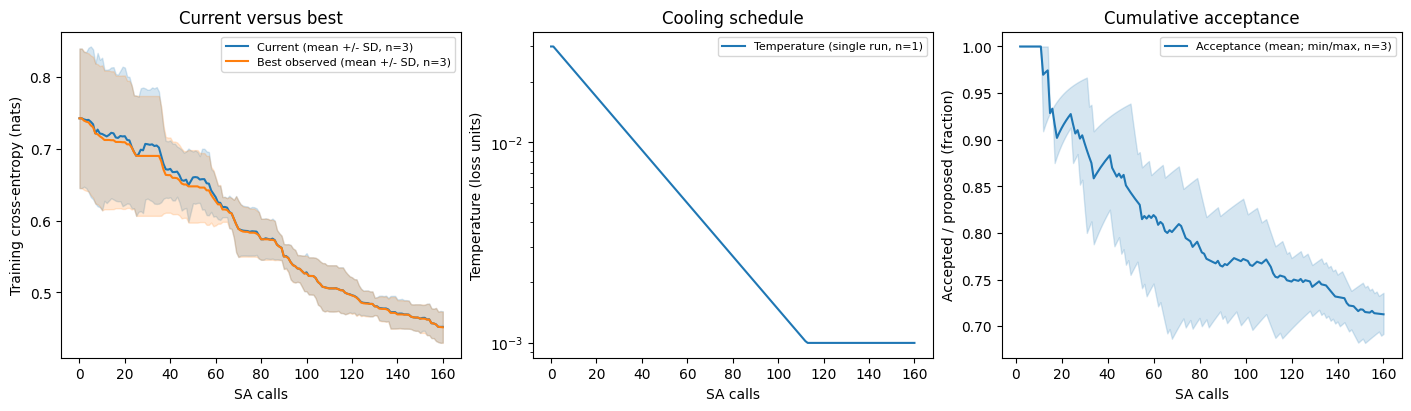

In [5]:
runs = results["Classification"]["SA"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout="constrained")
curve = prepare_training_curve(
    x,
    {
        "Current": np.array([r["train"] for r in runs]).T,
        "Best observed": np.array([r["best"] for r in runs]).T,
    },
    metric="Training cross-entropy (nats)",
    x_label="SA calls",
)
plot_training_curve(curve, ax=axes[0])
plot_training_curve(
    prepare_training_curve(
        x,
        {"Temperature": runs[0]["temperature"]},
        metric="Temperature (loss units)",
        x_label="SA calls",
    ),
    ax=axes[1],
)
axes[1].set_yscale("log")
plot_training_curve(
    prepare_training_curve(
        x[2:],
        {"Acceptance": np.array([r["acceptance"][2:] for r in runs]).T},
        metric="Accepted / proposed (fraction)",
        x_label="SA calls",
        uncertainty="range",
    ),
    ax=axes[2],
)
for ax, title in zip(
    axes, ["Current versus best", "Cooling schedule", "Cumulative acceptance"]
):
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.show()

The acceptance ribbon shows the observed minimum and maximum across seeds, not a
confidence interval. This within-run temperature schedule is a training diagnostic;
comparing validation scores across models trained at different temperatures would
be a validation curve.

Next: [learning and validation curves](03_learning_and_validation.ipynb).

In [6]:
print(f"Notebook computation and plotting: {perf_counter() - started:.2f} seconds")

Notebook computation and plotting: 1.66 seconds
